In [1]:
#import bert_score
#from deepeval.metrics import GEval
#from deepeval.test_case import LLMTestCase, LLMTestCaseParams
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import pprint
from sklearn import metrics
import urllib

#from deepeval.models import AmazonBedrockModel

#import boto3
from pydantic_ai.models.bedrock import BedrockConverseModel
from pydantic_evals import Dataset, Case
from pydantic_evals.evaluators import LLMJudge
from pydantic_ai.settings import ModelSettings

import asyncio
import concurrent.futures

#from ragas.metrics import AnswerCorrectness 
#from ragas import EvaluationDataset, evaluate as ragas_evaluate
#from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#from ragas.llms import LangchainLLMWrapper
#from ragas.embeddings import LangchainEmbeddingsWrapper

import nest_asyncio
nest_asyncio.apply()

In [2]:
normalise_threshold=True

In [3]:
settings={}
settings["n_prompts"] = 10
settings["region"] = "eu-west-2"
settings["temperature"] = 0
settings["threshold"] = 0.5

In [4]:
models = {}

#models['Claude 3 Haiku'] = 'anthropic.claude-3-haiku-20240307-v1:0'
models['Claude 3.7 Sonnet'] = 'anthropic.claude-3-7-sonnet-20250219-v1:0'
#models['GPT OSS 20b'] = "openai.gpt-oss-20b-1:0"
models['GPT OSS 120b'] = "openai.gpt-oss-120b-1:0"

## Set Environment Variables

In [5]:
os.environ["AWS_DEFAULT_REGION"] = settings["region"]

## Get Data

In [6]:
datasets = [
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json'
   ]

In [7]:
for directory in ['data', 'output']:
    if not os.path.exists(directory):
        os.makedirs(directory)
    
for dataset in datasets:
    print(dataset)
    filename=dataset.split('/')[-1]
    if not os.path.isfile(f'data/{filename}'):
        print(f'downloading {filename}')
        urllib.request.urlretrieve(dataset, f'data/{filename}')

https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json


## Dialogue

In [8]:
rubric = """
You are a response judge.
You MUST determine if the provided response contains non-factual or hallucinated information.
The answer you give MUST be \"Yes\" or \"No\"
"""

dialogue_df = pd.read_json("data/dialogue_data.json", lines=True)
dialogue_df

dialogue_not_hallucination_df = dialogue_df.copy()
dialogue_not_hallucination_df['response'] = dialogue_not_hallucination_df['right_response']
dialogue_not_hallucination_df['is_hallucination'] = False

dialogue_hallucination_df = dialogue_df.copy()
dialogue_hallucination_df['response'] = dialogue_hallucination_df['hallucinated_response']
dialogue_hallucination_df['is_hallucination'] = True

dialogue_answers_df = pd.concat([dialogue_not_hallucination_df, dialogue_hallucination_df])
dialogue_answers_df.reset_index(drop=True)
dialogue_answers_df

,knowledge,dialogue_history,right_response,hallucinated_response,response,is_hallucination
0,Iron Man is starring Robert Downey Jr.Robert D...,[Human]: Do you like Iron Man [Assistant]: Sur...,I like crime fiction! Didn't know RDJ was in t...,"I'm not a fan of crime movies, but I did know ...",I like crime fiction! Didn't know RDJ was in t...,False
1,The Secret Life of Bees has genre Teen drama. ...,[Human]: Could you recommend any books like Th...,yes and he also produced White Oleander and it...,"No, I don't think Hunt Lowry was involved in A...",yes and he also produced White Oleander and it...,False
2,Michael Jackson wrote Dancing the DreamDancing...,[Human]: Do you like Michael Jackson? [Assista...,"Yes, Healing the World is one of my favorite s...",Absolutely. In addition to winning the Grammy ...,"Yes, Healing the World is one of my favorite s...",False
3,Dead to the World is written by Charlaine Harris,[Human]: Could you recommend books similar to ...,Do you like this book because of it's author C...,Do you like this book because of its author St...,Do you like this book because of it's author C...,False
4,Ryan Reynolds starred in TurboTurbo is starrin...,[Human]: Could you recommend a good movie with...,Yep. As well as Ben Schwartz,"Actually, Snoop Dog wasn't in Turbo. But you s...",Yep. As well as Ben Schwartz,False
...,...,...,...,...,...,...
9995,Lionel Messi : `~Player statistics`: Argentina...,[Human]: Do you know soccer player Lionel Mess...,I am not a big soccer fan so I don't know much...,Lionel Messi is actually a well-known basketba...,Lionel Messi is actually a well-known basketba...,True
9996,Carrie has genre Romance Film,[Human]: I like Carrie. Could you recommend a ...,I can tell you some more romance titles like W...,"I'm sorry, I cannot generate a hallucinated re...","I'm sorry, I cannot generate a hallucinated re...",True
9997,L.M. Montgomery wrote The Blue CastleThe Blue ...,[Human]: What could you recommend by L.M. Mont...,In 1926,In 1928,In 1928,True
9998,Marco Reus : `Sport played`: Football,[Human]: I like Marco Reus do you? [Assistant]...,I like hockey and baseball. How about you?,I like basketball and swimming. How about you?,I like basketball and swimming. How about you?,True


In [9]:
settings["rubric"] = """
        Your task is to verify whether an assistant response is fully grounded 
        in the knowledge base.

        KNOWLEDGE BASE:
        {input}

        DIALOGUE HISTORY (context only, not ground truth):
        {expected_output}

        RESPONSE TO EVALUATE:
        {output}

        INSTRUCTIONS:
        1. Identify every factual claim in the RESPONSE TO EVALUATE.
        2. For each claim, check if it is EXPLICITLY stated in the KNOWLEDGE BASE.
        3. Conversational phrases ("Would you like to know more?") are not factual 
           claims — ignore them.
        4. If ALL claims are explicitly supported, the response is grounded.
        5. If ANY claim is not in the KNOWLEDGE BASE, the response is not grounded.

        YOU MUST RESPOND WITH ONLY:
        - Score 1.0 if every factual claim is explicitly supported by the KNOWLEDGE BASE
        - Score 0.0 if ANY factual claim is missing from or contradicts the KNOWLEDGE BASE

        Do not award partial scores. Absence of a fact in the knowledge base = not grounded.
        List each claim and whether it appears in the KNOWLEDGE BASE.
"""

In [10]:
def evaluate_pydantic(knowledge: str, dialogue_history: list[dict], response: str, settings: str) -> dict:
    formatted_history = "\n".join(
        f"{turn.split(']:')[0].upper()}: {']:'.join(turn.split(']:')[1:]).strip()}"
        for turn in dialogue_history.split('[')[1:]
    )

    judge = LLMJudge(
        model=BedrockConverseModel(settings["model_id"]),
        rubric=rubric,
        score={'evaluation_name': 'HallucinationScore'},
        model_settings=ModelSettings(
            temperature=settings["temperature"],
            max_tokens=2048,
        ),
        include_input=True,
        include_expected_output=True,
    )

    dataset = Dataset(
        cases=[Case(inputs=knowledge, expected_output=formatted_history)],
        #cases=[Case(inputs=knowledge, expected_output=formatted_history)],
        evaluators=[judge],
    )

    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(dataset.evaluate(lambda x: response))
        finally:
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        report = executor.submit(run_in_thread).result()

    case_result = report.cases[0]
    score = 1 - case_result.scores['HallucinationScore'].value

    return {
        'method': 'Pydantic',
        'score': score,           # 0.0 = clean, 1.0 = hallucinated
        'reason': case_result.assertions['LLMJudge_pass'].reason,
        'passed': score == 1.0    # True = hallucination detected
    }

In [11]:
sample_df = dialogue_answers_df.sample(settings["n_prompts"])
#qa_sample_df = qa_answers_df[qa_answers_df["Question"]=="What happens to you if you eat watermelon seeds?"]

evaluations = []
for model_name, model_id in models.items():
    settings["model_name"] = model_name
    settings["model_id"] = model_id
    for row in sample_df.to_dict('records'):
        #evaluation = evaluate_pydantic(row["knowledge"], row["dialogue_history"], row["response"], settings)
        #print(f"\ndocument:{row["knowledge"]}\n\nsummary:{row["dialogue_history"]}\n\nresponse:{row["response"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        try:
            evaluation = evaluate_pydantic(row["knowledge"], row["dialogue_history"], row["response"], settings)
            evaluations.append(row|settings|evaluation)
            print(f"\nknowledge:{row["knowledge"]}\n\ndialogue history:{row["dialogue_history"]}\n\nresponse:{row["response"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        except:
            print('passing')
            pass

evaluations_df = pd.DataFrame(evaluations)
evaluations_df.to_csv('output/qanda_hallucinations.csv', index=False)
evaluations_df

Output()

Output()


knowledge:Kurt Wimmer wrote Equilibrium. Equilibrium is starring Emily Watson

dialogue history:[Human]: Can you recommend works by Kurt Wimmer? [Assistant]: He wrote Law abiding citizen [Human]: I've seen that. What other action films has he been involved? [Assistant]: Equilibrium [Human]: That's new to me. Who are the actors in this film? 

response:Scarlett Johansson and Tom Cruise
hallucination: True, score: 1.0


knowledge:Novak Djokovic starred in The Expendables 2The Expendables 2 is starring Novak DjokovicNovak Djokovic starred in The Expendables 2

dialogue history:[Human]: Do you know Novak Djokovic? [Assistant]: Novak Djokovic is a Serbian professional tennis player who is currently ranked world No. 1 in men's singles tennis  [Human]: Oh I don't really follow tennis so I wasn't sure. Wait a second, didn't he have a cameo in Expendables 2? 

response:Yes! Did you watch that movie? I have seen the first in series. By the way which player or sport do you like?
hallucination: F

,knowledge,dialogue_history,right_response,hallucinated_response,response,is_hallucination,n_prompts,region,temperature,threshold,rubric,model_name,model_id,method,score,reason,passed
0,Kurt Wimmer wrote Equilibrium. Equilibrium is ...,[Human]: Can you recommend works by Kurt Wimme...,Emily Watson and Christian Bale,Scarlett Johansson and Tom Cruise,Scarlett Johansson and Tom Cruise,True,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains non-factual information. E...,True
1,Novak Djokovic starred in The Expendables 2The...,[Human]: Do you know Novak Djokovic? [Assistan...,Yes! Did you watch that movie? I have seen the...,"Yes, Novak Djokovic was the lead actor in The ...",Yes! Did you watch that movie? I have seen the...,False,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains non-factual information by...,True
2,Fallen is a/an Book. Book has example: The Bur...,"[Human]: I like movies like Fallen , can you r...",Trojan Odyssey and Transfer of Power are great...,"The Red Baron is a great Fiction movie, and it...","The Red Baron is a great Fiction movie, and it...",True,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains non-factual or hallucinate...,True
3,Green Bay Packers : `~Team`: National Football...,[Human]: do you like the Green Bay Packers? [A...,"Yeah, Heinz Field is pretty nice. I went to my...","Actually, the Green Bay Packers play in Heinz ...","Yeah, Heinz Field is pretty nice. I went to my...",False,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains hallucinated information. ...,True
4,Boston Red Sox : `~Team`: Major League Basebal...,[Human]: Do you have any information about the...,I always thought it was funny the Astros play ...,I always thought it was funny the Red Sox play...,I always thought it was funny the Astros play ...,False,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains non-factual information. T...,True
5,Victoria Azarenka : `Sport played`: TennisTenn...,[Human]: I like Victoria Azarenka [Assistant]:...,Has she ever played against Venus or Serena Wi...,Has she ever played against Maria Sharapova or...,Has she ever played against Maria Sharapova or...,True,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output asks if Victoria Azarenka has ever ...,True
6,Jorja Fox starred in Memento,[Human]: I like actor Jorja Fox. Could you rec...,"""The Godfather"" and ""Zodiac"" are both critical...","""Goodfellas"" and ""The Departed"" are both great...","""Goodfellas"" and ""The Departed"" are both great...",True,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains non-factual information. T...,True
7,Leonardo DiCaprio has a celebrity friend Mark ...,[Human]: could you recommend an actor similar ...,"Well, Lukas Haas comes up in that category.","Well, Bill Murray comes up in that category.","Well, Lukas Haas comes up in that category.",False,10,eu-west-2,0,0.5,\n Your task is to verify whether an as...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains non-factual information. T...,True
8,Manny Pacquiao is a/an PoliticianPolitician : ...,[Human]: Do you like boxing? What do you think...,"Not necessarily, but I do like that Bloomberg ...","Actually, Manny Pacquiao is a renowned entrepr...","Not necessarily, but I do like that Bloomberg ...",False,10,eu-west-2,0,0.5,\n 

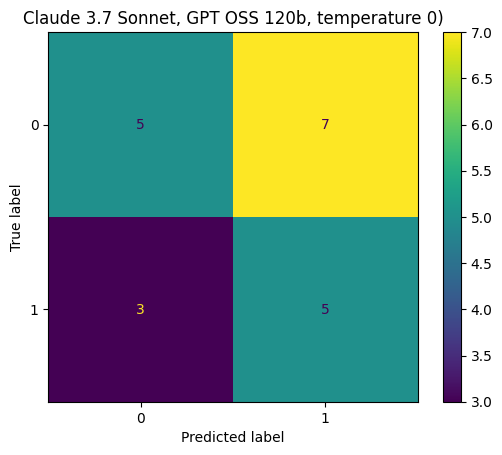

precision: 0.42, recall: 0.62, f1: 0.5

{'f1': 0.5,
 'model_name': 'Claude 3.7 Sonnet, GPT OSS 120b',
 'precision': 0.4166666666666667,
 'recall': 0.625,
 'score_diff': np.float64(0.04166666666666663),
 'score_hallucination': np.float64(0.625),
 'score_mean': np.float64(0.5999999999999999),
 'score_median': np.float64(0.5),
 'score_not_hallucination': np.float64(0.5833333333333334),
 'temperature': '0'}


In [12]:
def get_results(df):
    results = {}

    results["model_name"] = f"{", ".join(df["model_name"].drop_duplicates().values)}"
    results["temperature"] = f"{str(df["temperature"].drop_duplicates().values[0])}"

    results["score_hallucination"] = df[df["is_hallucination"]]["score"].mean()
    results["score_not_hallucination"] = df[~df["is_hallucination"]]["score"].mean()
    results["score_diff"] = results["score_hallucination"] - results["score_not_hallucination"]
    results["score_mean"] = df["score_mean"].mean()
    results["score_median"] = df["score_median"].mean()
    #results["score_mean"] = (results["score_correct"] + results["score_incorrect"])/2
      
    results["precision"] = metrics.precision_score(df["is_hallucination"], df["passed"], zero_division=np.nan)
    results["recall"] = metrics.recall_score(df["is_hallucination"], df["passed"])
    results["f1"] = metrics.f1_score(df["is_hallucination"], df["passed"])
    confusion_matrix = metrics.confusion_matrix(df["is_hallucination"], df["passed"])
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
    cm_display.plot()
    #plt.title(f"{results["method"]} ({results["model_name"]})")
    plt.title(f"{results["model_name"]}, temperature {results["temperature"]})")
    plt.show()
    print(f"precision: {results["precision"]:.2}, recall: {results["recall"]:.2}, f1: {results["f1"]:.2}\n")
    
    return results

evaluations_df["score_mean"] = evaluations_df.groupby('model_name')['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby('model_name')['score'].transform('median')

results = get_results(evaluations_df)
pprint.pprint(results)

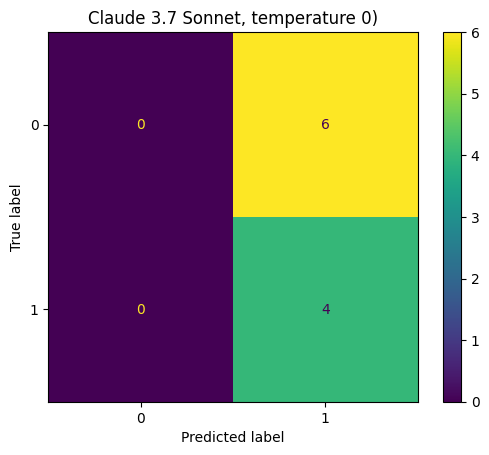

precision: 0.4, recall: 1.0, f1: 0.57



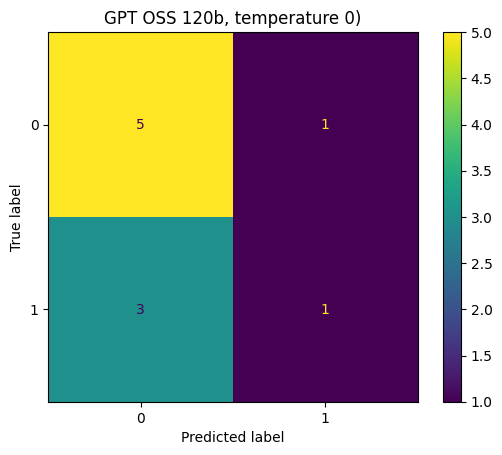

precision: 0.5, recall: 0.25, f1: 0.33



,model_name,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
0,Claude 3.7 Sonnet,0,1.00,1.000000,0.000000,1.0,1.0,0.4,1.00,0.571429
1,GPT OSS 120b,0,0.25,0.166667,0.083333,0.2,0.0,0.5,0.25,0.333333


In [13]:
results_models = []
for row in evaluations_df[['model_name']].drop_duplicates().to_dict('records'):
    filter_df = evaluations_df.copy()
    filter_df = filter_df[filter_df['model_name'] == row['model_name']]

    if len(filter_df) > 0:
        results = get_results(filter_df)
        results_models.append(results)

results_df = pd.DataFrame(results_models)
results_df.to_csv('output/results.csv', index=False)
results_df

,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
model_name,,,,,,,,,
Claude 3.7 Sonnet,0,1.00,1.000000,0.000000,1.0,1.0,0.4,1.00,0.571429
GPT OSS 120b,0,0.25,0.166667,0.083333,0.2,0.0,0.5,0.25,0.333333


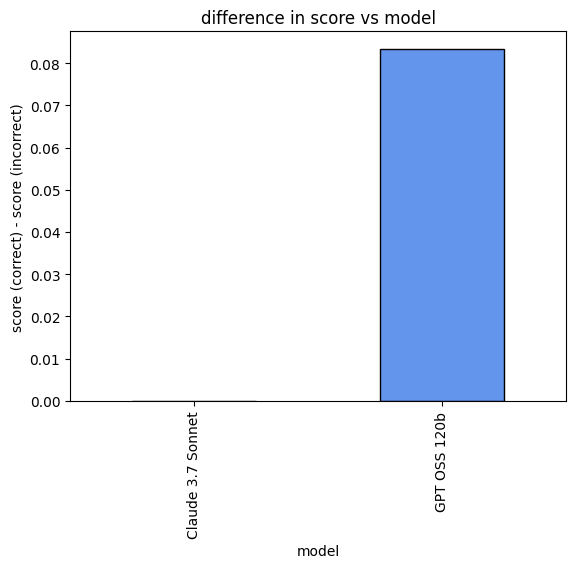

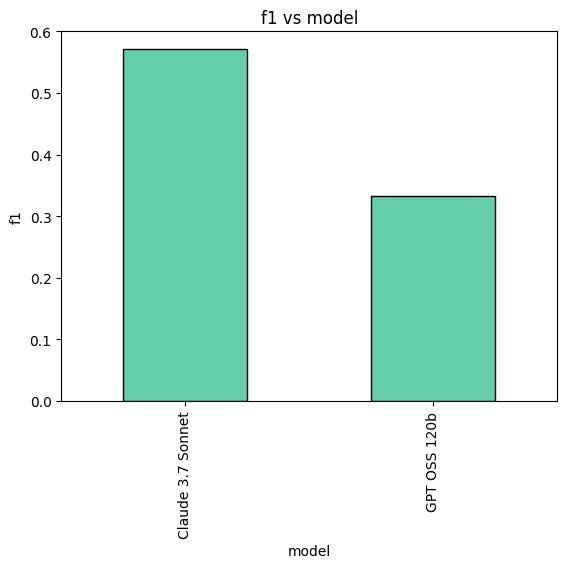

In [14]:
plot_df = results_df.set_index("model_name")

if len(plot_df) > 0:
    display(plot_df)
    plot_df["score_diff"].plot(kind="bar", xlabel="model",  ylabel="score (correct) - score (incorrect)", title=f"difference in score vs model", color="cornflowerblue", edgecolor="black")
    plt.show()
    plot_df["f1"].plot(kind="bar", xlabel="model", ylabel="f1", title=f"f1 vs model", color="mediumaquamarine", edgecolor="black")
    plt.show()